<a href="https://colab.research.google.com/github/abhiramanil369/BERT-Variant-Implementation/blob/main/BERTopic_Variant_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install sentence-transformers scikit-learn pandas matplotlib seaborn -q

In [ ]:
import random
import pandas as pd

templates = {
    "Finance": [
        "Your account was debited ₹{} for transaction at {}",
        "UPI payment of ₹{} received from {}",
        "Your credit card bill of ₹{} is due on {}",
    ],
    "Work": [
        "Meeting with {} scheduled at {}",
        "{} commented on your PR: '{}'",
        "Reminder: {} deadline is tomorrow",
    ],
    "Shopping": [
        "Your order #{} has been shipped via {}",
        "Exclusive {} sale — up to {}% off today only",
        "{} delivery arriving between {} and {}",
    ],
    "Family": [
        "{} sent you a voice message",
        "Mom: Don't forget {} tonight",
        "{} added you to group '{}'",
    ],
    "Urgent": [
        "OTP for your {} login is {}",
        "Security alert: New sign-in to your {} account",
        "Low battery: {} is at {}%",
    ],
}

names = ["Rahul", "Priya", "Arjun", "Neha", "Vikram", "Ananya"]
apps  = ["Swiggy", "Zomato", "HDFC", "Paytm", "GitHub", "Amazon"]
items = ["Pizza", "Laptop", "Shirt", "Phone case"]

rows = []
for _ in range(2000):
    cat = random.choice(list(templates.keys()))
    tmpl = random.choice(templates[cat])
    slots = tmpl.count("{}")
    fills = [random.choice(names + apps + items + [str(random.randint(100, 9999))])
             for _ in range(slots)]
    text = tmpl.format(*fills)
    rows.append({"text": text, "true_label": cat})

df = pd.DataFrame(rows).sample(frac=1).reset_index(drop=True)
print(df.head())

                                                text true_label
0                     Mom: Don't forget 8163 tonight     Family
1                     Mom: Don't forget HDFC tonight     Family
2               Mom: Don't forget Phone case tonight     Family
3  Your account was debited ₹1160 for transaction...    Finance
4  Security alert: New sign-in to your Pizza account     Urgent


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")  # 22 MB — same as the paper
embeddings = model.encode(df["text"].tolist(), batch_size=64, show_progress_bar=True)
print("Embedding shape:", embeddings.shape)  # (2000, 384)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=50, random_state=42)
reduced = pca.fit_transform(embeddings)

explained = np.cumsum(pca.explained_variance_ratio_)[-1]
print(f"Variance retained with 50 components: {explained:.1%}")
# Paper claims ~95% — you should see similar results

Variance retained with 50 components: 95.2%


In [ ]:
from sklearn.cluster import KMeans

K = 10  # paper uses 5–15; start with 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
df["topic_id"] = kmeans.fit_predict(reduced)
print(df["topic_id"].value_counts())

topic_id
8    574
9    259
3    257
6    149
1    136
0    135
4    131
2    125
7    124
5    110
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df["text"])
feature_names = vectorizer.get_feature_names_out()

topic_keywords = {}
for topic_id in range(K):
    mask = df["topic_id"] == topic_id
    cluster_tfidf = tfidf_matrix[mask.values].toarray().mean(axis=0)
    top_indices = cluster_tfidf.argsort()[-5:][::-1]
    topic_keywords[topic_id] = [feature_names[i] for i in top_indices]
    print(f"Topic {topic_id}: {topic_keywords[topic_id]}")

Topic 0: ['debited', 'transaction', 'account', 'laptop', 'shirt']
Topic 1: ['reminder', 'tomorrow', 'deadline', 'shirt', 'amazon']
Topic 2: ['new', 'alert', 'sign', 'security', 'account']
Topic 3: ['credit', 'card', 'upi', 'payment', 'received']
Topic 4: ['tonight', 'mom', 'don', 'forget', 'zomato']
Topic 5: ['zomato', 'meeting', 'scheduled', 'order', 'shipped']
Topic 6: ['voice', 'message', 'sent', 'hdfc', 'ananya']
Topic 7: ['low', 'battery', 'zomato', 'paytm', 'shirt']
Topic 8: ['order', 'shipped', 'meeting', 'scheduled', 'delivery']
Topic 9: ['otp', 'login', 'added', 'group', 'hdfc']


In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

sil = silhouette_score(reduced, df["topic_id"], sample_size=500)
print(f"Silhouette score: {sil:.3f}")  # Higher = better separation

# If you have true labels, compute ARI
ari = adjusted_rand_score(df["true_label"], df["topic_id"])
print(f"Adjusted Rand Index: {ari:.3f}")

Silhouette score: 0.158
Adjusted Rand Index: 0.459


2026-03-17 15:17:33.839133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773760654.110092      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773760654.191174      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773760654.773390      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773760654.773434      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773760654.773438      55 computation_placer.cc:177] computation placer alr

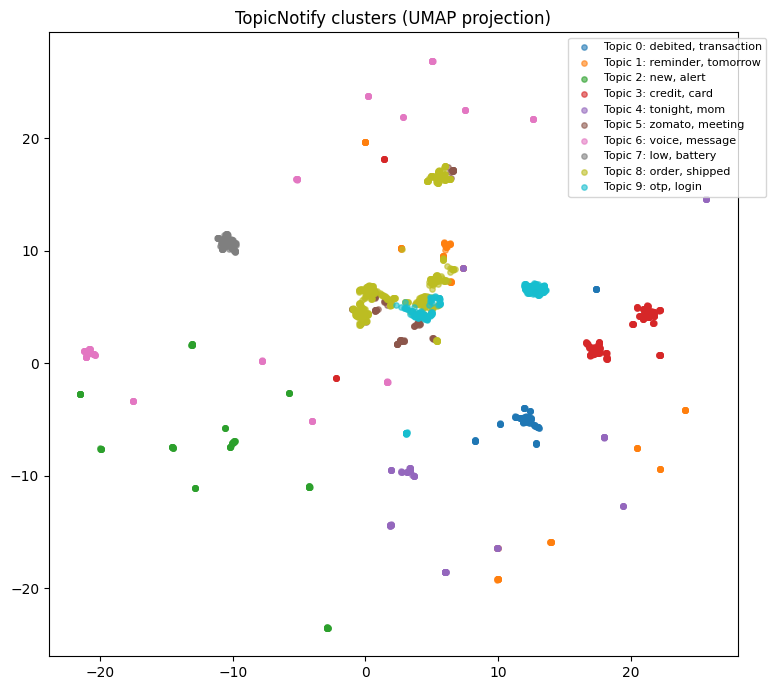

In [ ]:
!pip install umap-learn -q
import umap
import matplotlib.pyplot as plt
import seaborn as sns

reducer = umap.UMAP(random_state=42)
coords = reducer.fit_transform(reduced)

plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab10", K)
for i in range(K):
    mask = df["topic_id"] == i
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=f"Topic {i}: {', '.join(topic_keywords[i][:2])}",
                alpha=0.6, s=15, color=palette[i])
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.title("TopicNotify clusters (UMAP projection)")
plt.tight_layout()
plt.savefig("topic_clusters.png", dpi=150)
plt.show()

In [ ]:
df["keywords"] = df["topic_id"].map(
    lambda i: ", ".join(topic_keywords[i])
)

topic_table = (
    df.groupby(["topic_id", "keywords"])
    .agg(count=("text", "count"),
         sample=("text", lambda x: x.iloc[0]))
    .reset_index()
    .sort_values("count", ascending=False)
)
print(topic_table.to_string(index=False))

 topic_id                                     keywords  count                                                       sample
        8 order, shipped, meeting, scheduled, delivery    574                Your order #GitHub has been shipped via Arjun
        9               otp, login, added, group, hdfc    259                             OTP for your Neha login is Rahul
        3         credit, card, upi, payment, received    257          Your credit card bill of ₹Neha is due on Phone case
        6           voice, message, sent, hdfc, ananya    149                              Ananya sent you a voice message
        1  reminder, tomorrow, deadline, shirt, amazon    136                    Reminder: Phone case deadline is tomorrow
        0 debited, transaction, account, laptop, shirt    135 Your account was debited ₹1160 for transaction at Phone case
        4            tonight, mom, don, forget, zomato    131                               Mom: Don't forget 8163 tonight
        2       